In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df_no_adapt = pd.read_excel("../results/результаты.xlsx", sheet_name="без адаптации")
df_adapt_d_a = pd.read_excel("../results/результаты.xlsx", sheet_name="disc-ace")
df_adapt_a_d = pd.read_excel("../results/результаты.xlsx", sheet_name="ace-disc")

In [5]:
# df_adapt_a_d[df_adapt_a_d['adaptation_method'] == 'ace-disc-dann']

In [6]:
df = pd.concat([df_no_adapt, df_adapt_d_a, df_adapt_a_d], ignore_index=True)

df['scenario'][df['scenario'] == 'shuffle'] = 'комб.'
df['scenario'][df['scenario'] == 'ace-ace'] = 'A-A'
df['scenario'][df['scenario'] == 'ace-disc'] = 'A-D'
df['scenario'][df['scenario'] == 'disc-ace'] = 'D-A'
df['scenario'][df['scenario'] == 'disc-disc'] = 'D-D'

df['forecast_model'][df['forecast_model'] == 'Linear'] = 'ЛР'
df['forecast_model'][df['forecast_model'] == 'Ridge'] = 'ЛР L1'
df['forecast_model'][df['forecast_model'] == 'Lasso'] = 'ЛР L2'
df['forecast_model'][df['forecast_model'] == 'LGBM'] = 'ГБ'
df['forecast_model'][df['forecast_model'] == 'MLP'] = 'МСП'

df['adaptation_method'][df['adaptation_method'] == 'linreg'] = 'ЛР'
df['adaptation_method'][df['adaptation_method'] == 'lgbm'] = 'ГБ'
df['adaptation_method'][df['adaptation_method'] == 'pls'] = 'ПЛС'
df['adaptation_method'][df['adaptation_method'] == 'disc-ace-dann'] = 'D-A ДСНС'
df['adaptation_method'][df['adaptation_method'] == 'ace-disc-dann'] = 'A-D ДСНС'

df["adaptation_method"] = df["adaptation_method"].fillna("б/а")
df["scenario"] = df["scenario"].fillna("ДА")
df["scenario_adaptation"] = df["scenario"] + " " + df["adaptation_method"]

df['scenario_adaptation'].unique()
# df[df['adaptation_method'] == 'ace-disc-dann']

array(['A-A б/а', 'A-D б/а', 'D-A б/а', 'D-D б/а', 'комб. б/а', 'ДА ЛР',
       'ДА ГБ', 'ДА ПЛС', 'ДА D-A ДСНС', 'ДА A-D ДСНС'], dtype=object)

In [7]:
df

,target,delays,scenario,forecast_model,RMSE,MAE,R2,adaptation_method,scenario_adaptation
0,Dst_plus1,24h,A-A,ЛР,3.438899,2.401378,0.965960,б/а,A-A б/а
1,Dst_plus1,24h,A-A,ЛР L1,3.439189,2.401620,0.965954,б/а,A-A б/а
2,Dst_plus1,24h,A-A,ЛР L2,3.440365,2.401460,0.965931,б/а,A-A б/а
3,Dst_plus1,24h,A-A,ГБ,4.088073,2.476720,0.951895,б/а,A-A б/а
4,Dst_plus1,24h,A-A,МСП,3.735850,2.666253,0.959827,б/а,A-A б/а
...,...,...,...,...,...,...,...,...,...
615,Dst_plus6,auto_func,ДА,ЛР,10.020369,7.026770,0.709526,ПЛС,ДА ПЛС
616,Dst_plus6,auto_func,ДА,ЛР L1,10.020434,7.026793,0.709522,ПЛС,ДА ПЛС
617,Dst_plus6,auto_func,ДА,ЛР L2,10.016107,7.024580,0.709773,ПЛС,ДА ПЛС
618,Dst_plus6,auto_func,ДА,ГБ,10.144796,6.911939,0.702267,ПЛС,ДА ПЛС


In [39]:
# #RMSE
# plt.figure(figsize=(12, 5))
# ax = sns.barplot(
#     data=df_h_mod,
#     x="scenario_adaptation",
#     y="RMSE",
#     ci=None
#     # hue="forecast_model"
# )

# plt.title("RMSE для прогнозов на 1 час")
# plt.ylabel("RMSE")
# plt.xlabel("Сценарий обучения без адаптации или модель адаптации / тип адаптации")
# plt.xticks(rotation=30, ha="right")

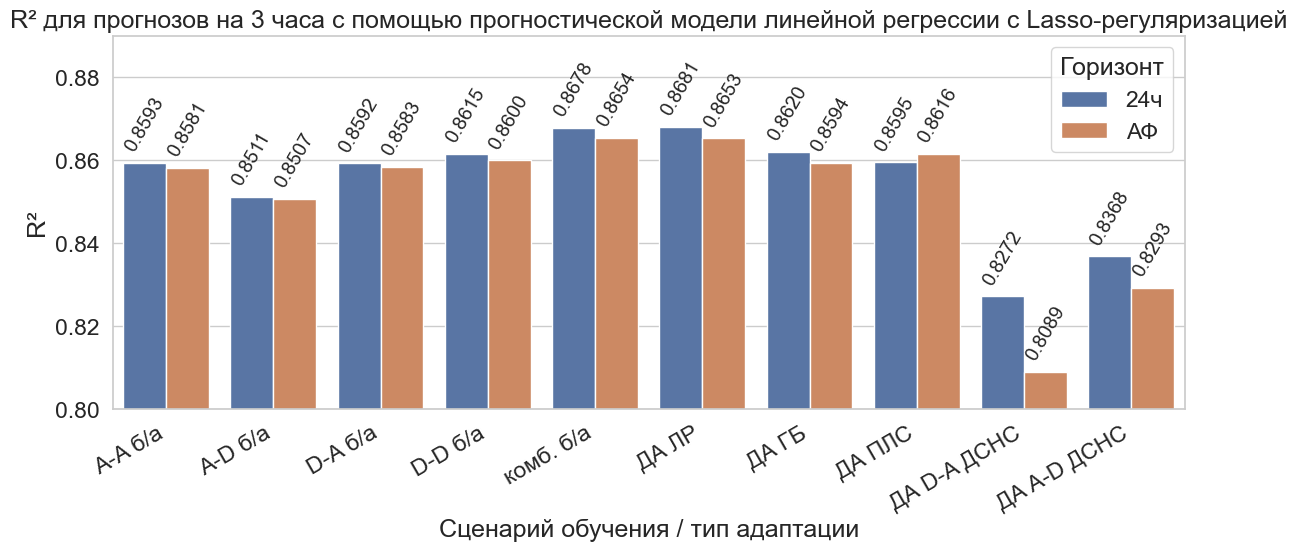

In [70]:
sns.set(style="whitegrid", font_scale=1.5)

target_name = "Dst_plus3"
# delays = '24h'
forecast_model = "ЛР L2"

df_h_mod = df[(df["target"] == target_name) &
              # (df["delays"] == delays) &
              (df["forecast_model"] == forecast_model)]

# R2
plt.figure(figsize=(12, 6))

# df_h_mod = df_h_mod.copy()
mapping = {
    "24h": "24ч",
    "auto_func": "АФ"
}
df_h_mod["delays"] = df_h_mod["delays"].replace(mapping)

ax = sns.barplot(
    data=df_h_mod,
    x="scenario_adaptation",
    y="R2",
    ci=None,
    hue="delays"
)

ax.legend(title="Горизонт", loc="best")

plt.title("R² для прогнозов на 3 часа c помощью прогностической модели линейной регрессии с Lasso-регуляризацией")
plt.ylabel("R²")
plt.xlabel("Сценарий обучения / тип адаптации")
plt.xticks(rotation=30, ha="right")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.4f}",
                (p.get_x() + p.get_width() / 2, height + 0.002),
                ha="center", va="bottom",
                fontsize=14, rotation=60)

plt.tight_layout()
# plt.ylim(0.91, 0.98)
# plt.ylim(0.6, 0.75)
plt.ylim(0.8, 0.89)
plt.show()

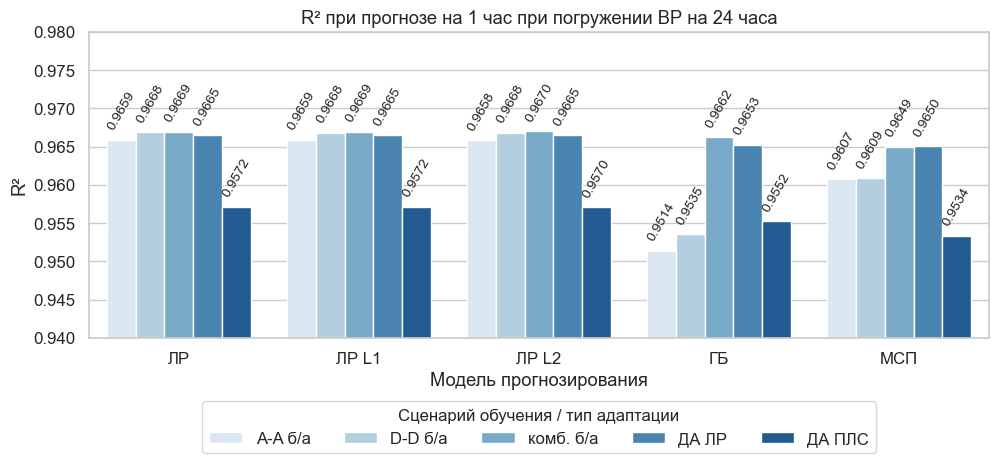

In [67]:
df_dd_aa = df[(df["target"] == "Dst_plus1") &
                 (df["scenario_adaptation"].isin(["A-A б/а", "D-D б/а", 'комб. б/а',
                                                 'ДА ЛР', 'ДА ПЛС']))]

# все варианты
# ['A-A б/а', 'A-D б/а', 'D-A б/а', 'D-D б/а', 'комб. б/а', 'ДА ЛР',
# 'ДА ГБ', 'ДА ПЛС', 'ДА D-A ДСНС', 'ДА A-D ДСНС']

# print(df_1h_dd_aa[["scenario_adaptation", "RMSE", "R2"]])

# RMSE
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(
#     data=df_1h_dd_aa,
#     x="forecast_model",
#     y="RMSE",
#     hue="scenario_adaptation",
#     ci=None
# )

# plt.title("RMSE для сценариев disc-disc и ace-ace, прогноз на 1 час")
# plt.ylabel("RMSE")
# plt.xlabel("Модель")
# plt.xticks(rotation=30, ha="right")

# for p in ax.patches:
#     height = p.get_height()
#     ax.annotate(f"{height:.2f}",
#                 (p.get_x() + p.get_width() / 2, height),
#                 ha="center", va="bottom",
#                 fontsize=9)

# plt.tight_layout()
# plt.ylim(3, 4)
# plt.show()

# R2
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_dd_aa,
    x="forecast_model",
    y="R2",
    hue="scenario_adaptation",
    palette="Blues",
    ci=None
)

plt.title("R² при прогнозе на 1 час при погружении ВР на 24 часа")
plt.ylabel("R²")
plt.xlabel("Модель прогнозирования")
# plt.xticks(rotation=30, ha="right")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.4f}",
                (p.get_x() + p.get_width() / 2, height + 0.001),
                ha="center", va="bottom",
                fontsize=10, rotation=60)

ax.legend(
    title="Сценарий обучения / тип адаптации",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=6,
    frameon=True,
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()
plt.ylim(0.94, 0.98)
# plt.ylim(0.55, 0.75)
# plt.ylim(0.78, 0.89)
plt.show()